In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns',None)

In [2]:
df = pd.read_csv('../data/cs-training.csv',index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
print(df.shape)
df.info()

(150000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dty

In [4]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [5]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [6]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [7]:
# Make a copy to keep raw df untouched
df_clean = df.copy()

# 1. Fix the "98" placeholder codes in the three late-payment columns
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse']

for col in late_cols:
    print(col, (df_clean[col] >= 90).sum(), "rows with placeholder codes")
    
print(df_clean['SeriousDlqin2yrs'].unique())

NumberOfTime30-59DaysPastDueNotWorse 269 rows with placeholder codes
NumberOfTimes90DaysLate 269 rows with placeholder codes
NumberOfTime60-89DaysPastDueNotWorse 269 rows with placeholder codes
[1 0]


In [8]:
for col in late_cols:
    real_max = df_clean.loc[df_clean[col] < 90,col].max()
    df_clean.loc[df_clean[col] >= 90, col] = real_max
    print(col, "capped at real_max")
    
print("Rows with age = 0:", (df_clean['age'] == 0).sum())
df_clean.loc[df_clean['age'] == 0, 'age'] = df_clean['age'].median()

print ("ROws with utilization > 2:", (df_clean['RevolvingUtilizationOfUnsecuredLines'] >2).sum())
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)

df_clean[late_cols + ['age','RevolvingUtilizationOfUnsecuredLines']].describe()

print(df_clean['SeriousDlqin2yrs'].unique())
df_clean['SeriousDlqin2yrs'].value_counts()


NumberOfTime30-59DaysPastDueNotWorse capped at real_max
NumberOfTimes90DaysLate capped at real_max
NumberOfTime60-89DaysPastDueNotWorse capped at real_max
Rows with age = 0: 1
ROws with utilization > 2: 371
[1 0]


SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [9]:
print (df_clean['MonthlyIncome'].describe())

median_income = df_clean['MonthlyIncome'].median()
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(median_income)

print(df_clean['NumberOfDependents'].value_counts().head())
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(0)

df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(0)


df_clean.isnull().sum()


count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64
NumberOfDependents
0.0    86902
1.0    26316
2.0    19522
3.0     9483
4.0     2862
Name: count, dtype: int64


SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [10]:
df_clean['TotalPastDue'] = (
    df_clean['NumberOfTime30-59DaysPastDueNotWorse'] +
    df_clean['NumberOfTimes90DaysLate'] +
    df_clean['NumberOfTime60-89DaysPastDueNotWorse']
)

df_clean['IncomePerDependent'] = df_clean['MonthlyIncome'] / (df_clean['NumberOfDependents'] + 1)

df_clean['CreditLinesPerAge'] = df_clean['NumberOfOpenCreditLinesAndLoans'] / df_clean['age']

df_clean['HasRealEstateLoan'] = (df_clean['NumberRealEstateLoansOrLines'] > 0).astype(int)

df_clean.head()



,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalPastDue,IncomePerDependent,CreditLinesPerAge,HasRealEstateLoan
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,2,3040.0,0.288889,1
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,1300.0,0.100000,0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,2,3042.0,0.052632,0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,3300.0,0.166667,0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1,63588.0,0.142857,1


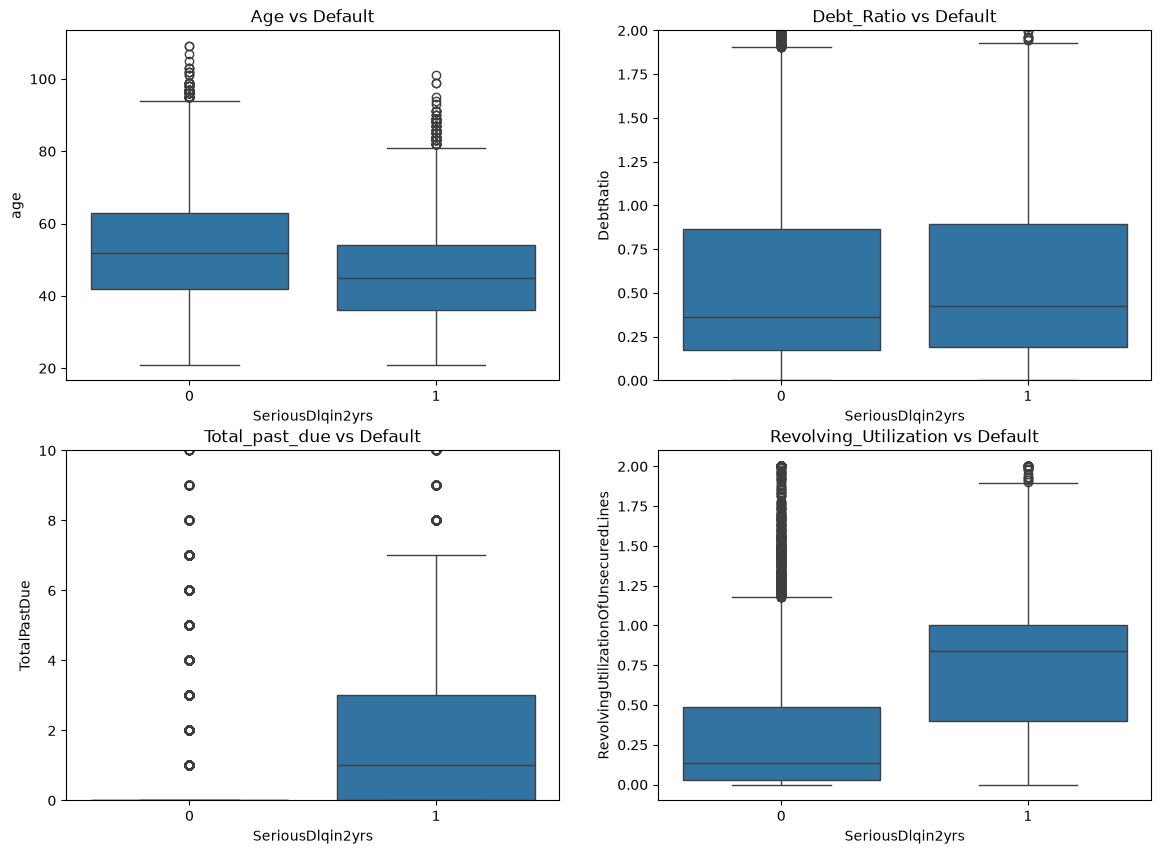

In [11]:
fig ,axes = plt.subplots(2,2,figsize=(14,10))

sns.boxplot(data=df_clean,x='SeriousDlqin2yrs',y='age', ax = axes[0,0])
axes[0,0].set_title('Age vs Default')

sns.boxplot(data=df_clean,x='SeriousDlqin2yrs',y='DebtRatio', ax = axes[0,1])
axes[0,1].set_ylim(0,2)
axes[0,1].set_title('Debt_Ratio vs Default')

sns.boxplot(data=df_clean,x='SeriousDlqin2yrs',y='TotalPastDue', ax = axes[1,0])
axes[1,0].set_ylim(0,10)
axes[1,0].set_title('Total_past_due vs Default')

sns.boxplot(data=df_clean,x='SeriousDlqin2yrs',y='RevolvingUtilizationOfUnsecuredLines', ax = axes[1,1])
axes[1,1].set_title('Revolving_Utilization vs Default')

plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X=df_clean.drop('SeriousDlqin2yrs',axis=1)
y=df_clean['SeriousDlqin2yrs']

X_train,X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42, stratify=y
)

print(X_train.shape,X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(120000, 14) (30000, 14)
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64
SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [18]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled,y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:,1]

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Confusion Matrix:
[[22483  5512]
 [  506  1499]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.21      0.75      0.33      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000

ROC-AUC Score: 0.8586552283338804


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf=rf.predict_proba(X_test)[:, 1]

d:\codeAlpha_tasks\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\codeAlpha_tasks\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\codeAlpha_tasks\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\codeAlpha_tasks\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.pa

In [27]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))

Confusion Matrix:
[[23173  4822]
 [  505  1500]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     27995
           1       0.24      0.75      0.36      2005

    accuracy                           0.82     30000
   macro avg       0.61      0.79      0.63     30000
weighted avg       0.93      0.82      0.86     30000

ROC-AUC Score: 0.866801321397346
